In [24]:
import pandas as pd

In [25]:
data = pd.read_csv('HousingData.csv')

In [26]:
data.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,NaN,36.2


In [27]:
data.isna().sum()

CRIM       20
ZN         20
INDUS      20
CHAS       20
NOX         0
RM          0
AGE        20
DIS         0
RAD         0
TAX         0
PTRATIO     0
B           0
LSTAT      20
MEDV        0
dtype: int64

In [28]:
for col in data.columns:
    mean_val= data[col].mean()
    data[col].fillna(mean_val,inplace=True)
data.isna().sum()

C:\Users\HP\AppData\Local\Temp\ipykernel_16108\1165102071.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data[col].fillna(mean_val,inplace=True)


CRIM       0
ZN         0
INDUS      0
CHAS       0
NOX        0
RM         0
AGE        0
DIS        0
RAD        0
TAX        0
PTRATIO    0
B          0
LSTAT      0
MEDV       0
dtype: int64

In [29]:
data.describe()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
count,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000
mean,3.611874,11.211934,11.083992,0.069959,0.554695,6.284634,68.518519,3.795043,9.549407,408.237154,18.455534,356.674032,12.715432,22.532806
std,8.545770,22.921051,6.699165,0.250233,0.115878,0.702617,27.439466,2.105710,8.707259,168.537116,2.164946,91.294864,7.012739,9.197104
min,0.006320,0.000000,0.460000,0.000000,0.385000,3.561000,2.900000,1.129600,1.000000,187.000000,12.600000,0.320000,1.730000,5.000000
25%,0.083235,0.000000,5.190000,0.000000,0.449000,5.885500,45.925000,2.100175,4.000000,279.000000,17.400000,375.377500,7.230000,17.025000
50%,0.290250,0.000000,9.900000,0.000000,0.538000,6.208500,74.450000,3.207450,5.000000,330.000000,19.050000,391.440000,11.995000,21.200000
75%,3.611874,11.211934,18.100000,0.000000,0.624000,6.623500,93.575000,5.188425,24.000000,666.000000,20.200000,396.225000,16.570000,25.000000
max,88.976200,100.000000,27.740000,1.000000,0.871000,8.780000,100.000000,12.126500,24.000000,711.000000,22.000000,396.900000,37.970000,50.000000


In [30]:
data.columns

Index(['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX',
       'PTRATIO', 'B', 'LSTAT', 'MEDV'],
      dtype='object')

In [31]:
data.shape

(506, 14)

In [32]:
X= data.drop('MEDV',axis=1)
y=data['MEDV']

In [33]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.3,random_state=42)

sc=StandardScaler()
X_train_scaled = sc.fit_transform(X_train)
X_test_scaled= sc.transform(X_test)

In [34]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [35]:
model = Sequential()
model.add(Dense(128,input_shape=(13,),activation='relu',name='dense_1'))

model.add(Dense(64,activation='relu',name='dense_2'))

model.add(Dense(1,activation='linear',name='dense_output'))

model.compile(optimizer='adam',loss='mse',metrics=['mae'])

C:\Users\HP\AppData\Local\Programs\Python\Python39\lib\site-packages\keras\src\layers\core\dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [36]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_1 (Dense)                      │ (None, 128)                 │           1,792 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_output (Dense)                 │ (None, 1)                   │              65 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 10,113 (39.50 KB)

 Trainable params: 10,113 (39.50 KB)

 Non-trainable params: 0 (0.00 B)

In [37]:
history= model.fit(
    X_train_scaled,
    y_train,
    epochs=100,
    validation_split=0.05,
    verbose=1
)


Epoch 1/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 5s 87ms/step - loss: 596.6715 - mae: 22.6574 - val_loss: 497.4490 - val_mae: 20.7122
Epoch 2/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 527.2797 - mae: 21.0249 - val_loss: 415.3286 - val_mae: 18.7348
Epoch 3/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 431.1864 - mae: 18.7805 - val_loss: 314.0038 - val_mae: 15.9803
Epoch 4/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - loss: 315.7402 - mae: 15.7817 - val_loss: 203.1947 - val_mae: 12.2490
Epoch 5/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 198.3454 - mae: 11.8646 - val_loss: 115.3754 - val_mae: 8.2335
Epoch 6/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 88.8731 - mae: 7.4854 - val_loss: 74.1519 - val_mae: 5.9361
Epoch 7/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 52.0313 - mae: 5.7852 - val_loss: 60.8272 - val_mae: 5.4347
Epoch 8/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - loss: 38.6321 - mae: 4.9714 - val_loss: 55.4831 - val_mae: 5.0501
Epoch 9/100
11/11 ━━━

In [38]:
history.history

{'loss': [590.8235473632812,
  509.8953552246094,
  410.0602722167969,
  289.5334167480469,
  168.93704223632812,
  82.32962799072266,
  54.0707893371582,
  39.965919494628906,
  31.307905197143555,
  27.109176635742188,
  25.231624603271484,
  23.40346336364746,
  21.98958969116211,
  20.976926803588867,
  20.044055938720703,
  19.159103393554688,
  18.35218620300293,
  17.76392936706543,
  17.083255767822266,
  16.572261810302734,
  16.10280418395996,
  15.658302307128906,
  15.274672508239746,
  14.864222526550293,
  14.63129711151123,
  14.359477996826172,
  14.057256698608398,
  13.725208282470703,
  13.598752975463867,
  13.2182035446167,
  13.069319725036621,
  12.90757942199707,
  12.779401779174805,
  12.410211563110352,
  12.308158874511719,
  12.133882522583008,
  12.108892440795898,
  11.974818229675293,
  11.70363712310791,
  11.531610488891602,
  11.432371139526367,
  11.358095169067383,
  11.292399406433105,
  11.110016822814941,
  11.020894050598145,
  10.96139812469482

In [39]:
mse_nn, mae_nn = model.evaluate(X_test_scaled, y_test)
print('Mean squared error on test data: ', mse_nn) 
print('Mean absolute error on test data: ', mae_nn) 

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 9.1282 - mae: 2.1737
Mean squared error on test data:  10.67928695678711
Mean absolute error on test data:  2.1756584644317627


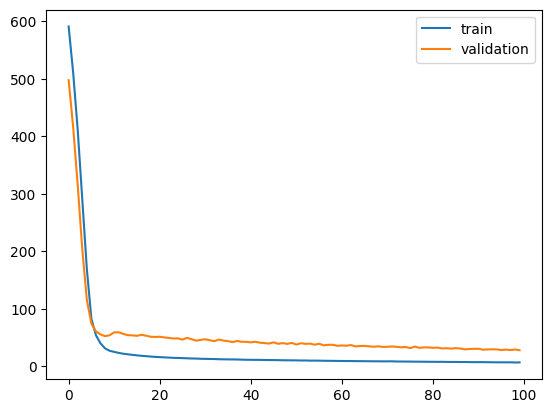

In [40]:
import matplotlib.pyplot as plt

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.legend(['train','validation'])
plt.show()